# Naive Bayes

## Overview

Naive Bayes applies Bayes' theorem with the strong assumption that features are conditionally independent given the class. Despite this rarely being true, it often performs well and is extremely fast.

**Variants by feature type:**

| Variant | Feature type | Typical use |
|---|---|---|
| `GaussianNB` | Continuous (assumes normal) | General classification |
| `MultinomialNB` | Non-negative counts | Text (word counts), species counts |
| `BernoulliNB` | Binary (0/1) | Presence/absence, document classification |
| `ComplementNB` | Counts, imbalanced | Text classification |

Naive Bayes is a strong baseline: if a complex model does not substantially outperform it, revisit the feature engineering before adding complexity.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from scipy.special import expit

rng = np.random.default_rng(42)
n = 400
elevation  = rng.uniform(50, 400, n)
nitrate    = rng.gamma(2, 2, n)
phosphorus = rng.gamma(1.5, 1.5, n)
ph         = rng.normal(7.2, 0.5, n)
log_odds   = -2 + 0.004*elevation - 0.2*nitrate + 0.35*ph
label = (expit(log_odds) > 0.5).astype(int)
X = np.column_stack([elevation, nitrate, phosphorus, ph])
feat_names = ["elevation","nitrate","phosphorus","ph"]
X_tr, X_te, y_tr, y_te = train_test_split(X, label, test_size=0.25,
                                            stratify=label, random_state=42)

---
## GaussianNB: Fitting and Evaluation

In [2]:
gnb = GaussianNB()
gnb.fit(X_tr, y_tr)
print(f"Test accuracy: {gnb.score(X_te, y_te):.3f}")
print(f"Test AUC-ROC:  {roc_auc_score(y_te, gnb.predict_proba(X_te)[:,1]):.3f}")
print(classification_report(y_te, gnb.predict(X_te), target_names=["absent","present"]))
# Learned class-conditional means
for i, cls in enumerate(["absent","present"]):
    print(f"\nClass {cls}: theta (means) = {dict(zip(feat_names, gnb.theta_[i].round(2)))}")

Test accuracy: 0.950
Test AUC-ROC:  0.982
              precision    recall  f1-score   support

      absent       1.00      0.67      0.80        15
     present       0.94      1.00      0.97        85

    accuracy                           0.95       100
   macro avg       0.97      0.83      0.89       100
weighted avg       0.95      0.95      0.95       100


Class absent: theta (means) = {'elevation': np.float64(168.23), 'nitrate': np.float64(7.91), 'phosphorus': np.float64(2.15), 'ph': np.float64(7.06)}

Class present: theta (means) = {'elevation': np.float64(241.03), 'nitrate': np.float64(3.13), 'phosphorus': np.float64(2.18), 'ph': np.float64(7.25)}


---
## Calibration Check

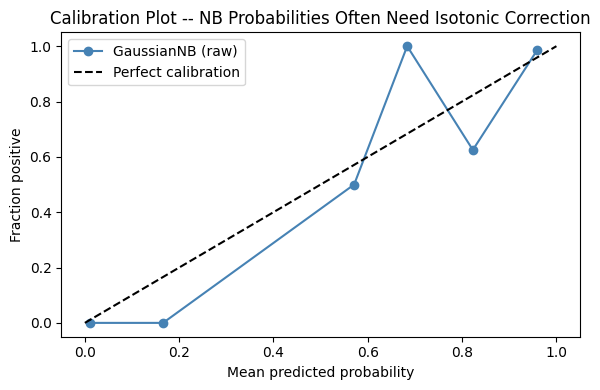

In [3]:
# Naive Bayes probabilities are often overconfident
frac, mean_pred = calibration_curve(y_te, gnb.predict_proba(X_te)[:,1], n_bins=8)
plt.figure(figsize=(6,4))
plt.plot(mean_pred, frac, "o-", color="steelblue", label="GaussianNB (raw)")
plt.plot([0,1],[0,1],"k--", label="Perfect calibration")
plt.xlabel("Mean predicted probability"); plt.ylabel("Fraction positive")
plt.title("Calibration Plot -- NB Probabilities Often Need Isotonic Correction")
plt.legend(); plt.tight_layout(); plt.show()

---
## Isotonic Calibration

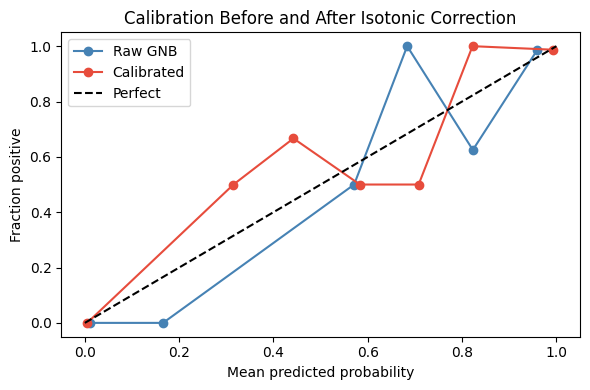

Raw AUC:        0.982
Calibrated AUC: 0.981


In [4]:
gnb_cal = CalibratedClassifierCV(GaussianNB(), cv=5, method="isotonic")
gnb_cal.fit(X_tr, y_tr)
frac_cal, mean_cal = calibration_curve(y_te, gnb_cal.predict_proba(X_te)[:,1], n_bins=8)
plt.figure(figsize=(6,4))
plt.plot(mean_pred, frac,     "o-", color="steelblue", label="Raw GNB")
plt.plot(mean_cal,  frac_cal, "o-", color="#e74c3c",   label="Calibrated")
plt.plot([0,1],[0,1],"k--", label="Perfect")
plt.xlabel("Mean predicted probability"); plt.ylabel("Fraction positive")
plt.title("Calibration Before and After Isotonic Correction")
plt.legend(); plt.tight_layout(); plt.show()
print(f"Raw AUC:        {roc_auc_score(y_te, gnb.predict_proba(X_te)[:,1]):.3f}")
print(f"Calibrated AUC: {roc_auc_score(y_te, gnb_cal.predict_proba(X_te)[:,1]):.3f}")

---
## BernoulliNB for Presence/Absence Data

In [5]:
# Binarise features at median split to simulate presence/absence
X_bin = (X > np.median(X, axis=0)).astype(int)
X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(X_bin, label, test_size=0.25,
                                                    stratify=label, random_state=42)
bnb = BernoulliNB(alpha=1.0)  # alpha: Laplace smoothing
bnb.fit(X_tr_b, y_tr_b)
print(f"BernoulliNB (binary features) Test AUC: {roc_auc_score(y_te_b, bnb.predict_proba(X_te_b)[:,1]):.3f}")
print("Log feature probabilities per class:")
for i, cls in enumerate(["absent","present"]):
    probs = np.exp(bnb.feature_log_prob_[i]).round(3)
    print(f"  {cls}: {dict(zip(feat_names, probs))}")

BernoulliNB (binary features) Test AUC: 0.849
Log feature probabilities per class:
  absent: {'elevation': np.float64(0.289), 'nitrate': np.float64(0.978), 'phosphorus': np.float64(0.533), 'ph': np.float64(0.422)}
  present: {'elevation': np.float64(0.575), 'nitrate': np.float64(0.409), 'phosphorus': np.float64(0.486), 'ph': np.float64(0.537)}


---

## Common Pitfalls

**1. Using GaussianNB on count or heavily skewed data**  
GaussianNB assumes each feature is normally distributed within each class. For count data or right-skewed features like nitrate or species abundance, use MultinomialNB (after scaling to non-negative integers) or log-transform before applying GaussianNB.

**2. Trusting Naive Bayes probabilities without calibration**  
The independence assumption causes NB to push probabilities toward 0 and 1. Raw probabilities are overconfident and unreliable for decision-making. Always check the calibration plot and apply isotonic or Platt calibration.

**3. Assuming Naive Bayes fails when features are correlated**  
Strongly correlated features reduce NB accuracy, but NB often remains a competitive baseline even with moderate correlation. Always benchmark it before discarding it on grounds of the independence assumption.

**4. Setting alpha=0 (no smoothing) for BernoulliNB or MultinomialNB**  
If a feature-class combination never appears in training, its probability is zero and NB assigns zero probability to any test point containing it regardless of other features. Always use Laplace smoothing (alpha >= 1) or at minimum alpha=0.1.

**5. Not using Naive Bayes as a baseline**  
Naive Bayes trains in milliseconds and is surprisingly competitive. If your tuned Random Forest only slightly outperforms GaussianNB, the marginal gain may not justify the complexity cost. Always include NB in model comparison.

---
*python_methods_library - Samantha McGarrigle*